In [1]:
# Task 2: Unsupervised Learning - Customer Segmentation
# Objective: Find patterns in unlabeled data using clustering
# Dataset: Mall Customer Segmentation Data from Kaggle

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

print("Customer Segmentation - Unsupervised Learning Task \n")

Customer Segmentation - Unsupervised Learning Task 



In [3]:
# Step 1: Load the dataset
print("Step 1: Loading the dataset...")

Step 1: Loading the dataset...


In [4]:
# Option 1: Try to load from Kaggle dataset
try:
    df = pd.read_csv('Mall_Customers.csv')
    print(f"Dataset loaded successfully! Shape: {df.shape}")
    print("Columns:", list(df.columns))
except FileNotFoundError:
    print("Mall_Customers.csv not found. Creating sample data...")
    # Create sample data for demonstration
    np.random.seed(42)
    df = pd.DataFrame({
        'CustomerID': range(1, 201),
        'Gender': np.random.choice(['Male', 'Female'], 200),
        'Age': np.random.randint(18, 70, 200),
        'Annual Income (k$)': np.random.randint(15, 140, 200),
        'Spending Score (1-100)': np.random.randint(1, 100, 200)
    })
    print("Sample data created for demonstration")
    print(f"Dataset shape: {df.shape}")

Dataset loaded successfully! Shape: (200, 5)
Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [5]:
# Step 2: Explore the data
print("\nStep 2: Data Exploration...")
print("First few rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nDataset Statistics:")
print(df.describe())

if 'Gender' in df.columns:
    print(f"\nGender distribution:")
    print(df['Gender'].value_counts())



Step 2: Data Exploration...
First few rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+

In [6]:
# Step 3: Data preprocessing
print("\nStep 3: Data Preprocessing...")

# Select numerical features for clustering
# Common column names in different datasets
possible_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 
                   'AnnualIncome', 'SpendingScore', 'Income', 'Score']

# Find which columns exist in our dataset
clustering_features = []
for col in df.columns:
    if any(possible_col.lower() in col.lower() for possible_col in ['age', 'income', 'spend', 'score']):
        if df[col].dtype in ['int64', 'float64']:
            clustering_features.append(col)

# If no appropriate columns found, use the first few numeric columns
if len(clustering_features) < 2:
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
    clustering_features = numeric_columns[:3]  # Take first 3 numeric columns

print(f"Features selected for clustering: {clustering_features}")

# Create clustering dataset
X = df[clustering_features].copy()
print(f"Clustering data shape: {X.shape}")

# Check for missing values
print(f"Missing values: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())


Step 3: Data Preprocessing...
Features selected for clustering: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Clustering data shape: (200, 3)
Missing values: 0


In [7]:
# Step 4: Standardize the features
print("\nStep 4: Feature Standardization...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)

print("Features standardized successfully!")
print("Standardized data sample:")
print(X_scaled_df.head())



Step 4: Feature Standardization...
Features standardized successfully!
Standardized data sample:
        Age  Annual Income (k$)  Spending Score (1-100)
0 -1.424569           -1.738999               -0.434801
1 -1.281035           -1.738999                1.195704
2 -1.352802           -1.700830               -1.715913
3 -1.137502           -1.700830                1.040418
4 -0.563369           -1.662660               -0.395980


In [8]:
pip install --upgrade scikit-learn threadpoolctl

Note: you may need to restart the kernel to use updated packages.



Step 5: Finding optimal number of clusters...
Calculating WCSS and Silhouette scores...
Optimal k based on silhouette score: 6


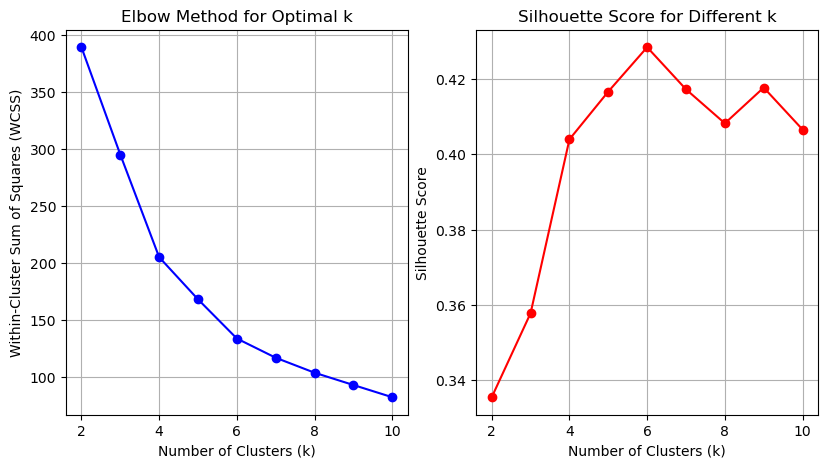

In [11]:
# Step 5: Determine optimal number of clusters using Elbow Method
print("\nStep 5: Finding optimal number of clusters...")

inertias = []
silhouette_scores = []
k_range = range(2, 11)  # Start from 2 for silhouette score

print("Calculating WCSS and Silhouette scores...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)

# Plot elbow method
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.grid(True)

# Choose optimal k (you can modify this logic)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal k based on silhouette score: {optimal_k}")


In [12]:
# Step 6: Apply K-means clustering
print(f"\nStep 6: Applying K-means clustering with k={optimal_k}...")

# Fit final K-means model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels
print(f"Clustering completed! Created {optimal_k} clusters")


Step 6: Applying K-means clustering with k=6...
Clustering completed! Created 6 clusters


In [13]:
# Step 7: Analyze clusters
print("\nStep 7: Cluster Analysis...")

# Cluster summary statistics
print("Cluster Summary Statistics:")
cluster_summary = df.groupby('Cluster')[clustering_features].mean()
print(cluster_summary)

print(f"\nCluster sizes:")
cluster_counts = df['Cluster'].value_counts().sort_index()
print(cluster_counts)


Step 7: Cluster Analysis...
Cluster Summary Statistics:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        56.333333           54.266667               49.066667
1        26.794872           57.102564               48.128205
2        41.939394           88.939394               16.969697
3        32.692308           86.538462               82.128205
4        25.000000           25.260870               77.608696
5        45.523810           26.285714               19.380952

Cluster sizes:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64



Step 8: Creating cluster visualizations...


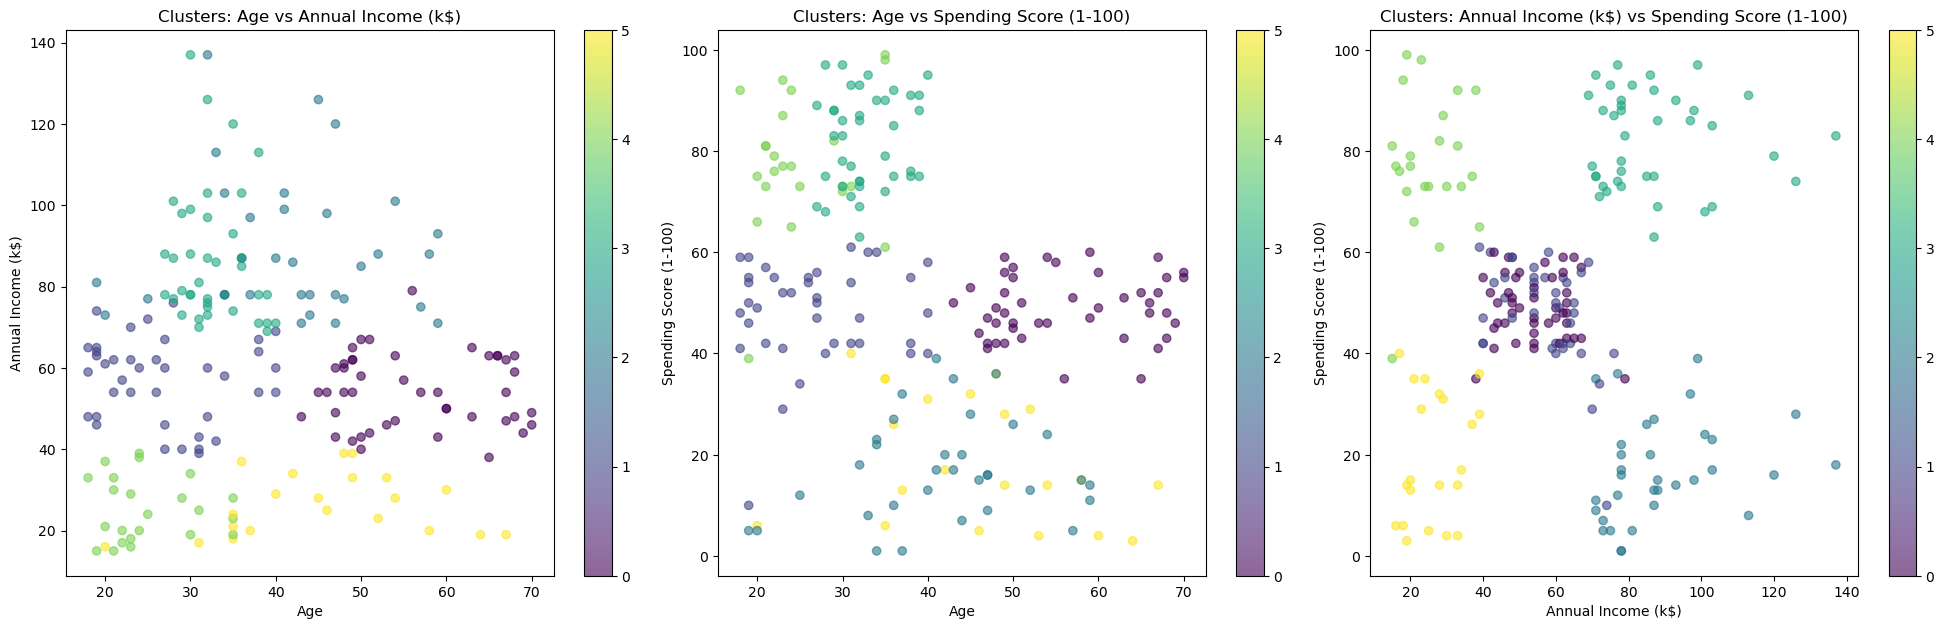

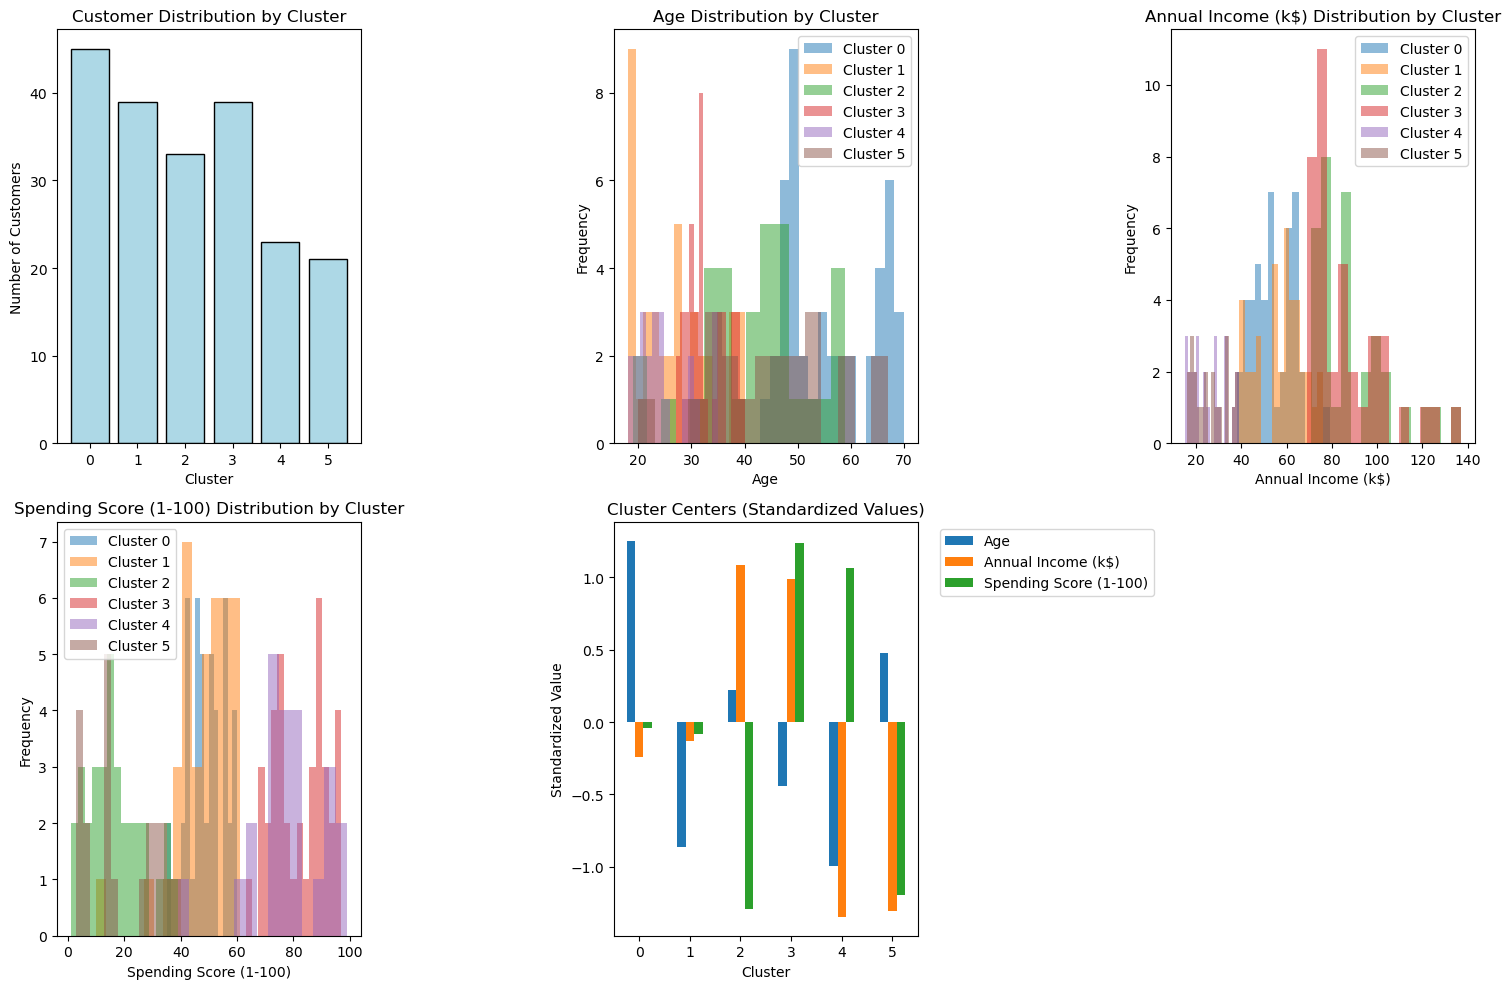

In [14]:
# Step 8: Visualize clusters
print("\nStep 8: Creating cluster visualizations...")

plt.figure(figsize=(20, 12))

# Determine number of feature combinations to plot
n_features = len(clustering_features)
plot_count = 0

# Plot pairwise feature combinations
for i in range(n_features):
    for j in range(i+1, n_features):
        if plot_count < 6:  # Limit to 6 plots
            plt.subplot(2, 3, plot_count + 1)
            scatter = plt.scatter(df[clustering_features[i]], df[clustering_features[j]], 
                                c=df['Cluster'], cmap='viridis', alpha=0.6)
            plt.xlabel(clustering_features[i])
            plt.ylabel(clustering_features[j])
            plt.title(f'Clusters: {clustering_features[i]} vs {clustering_features[j]}')
            plt.colorbar(scatter)
            plot_count += 1

plt.tight_layout()
plt.show()

# Additional visualizations
plt.figure(figsize=(15, 10))

# Cluster distribution
plt.subplot(2, 3, 1)
plt.bar(cluster_counts.index, cluster_counts.values, color='lightblue', edgecolor='black')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Cluster')

# Feature distributions by cluster
for idx, feature in enumerate(clustering_features[:3]):  # Plot first 3 features
    plt.subplot(2, 3, idx + 2)
    for cluster in sorted(df['Cluster'].unique()):
        cluster_data = df[df['Cluster'] == cluster][feature]
        plt.hist(cluster_data, alpha=0.5, label=f'Cluster {cluster}', bins=15)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'{feature} Distribution by Cluster')
    plt.legend()

# Cluster centers visualization
plt.subplot(2, 3, 5)
centers_df = pd.DataFrame(final_kmeans.cluster_centers_, 
                         columns=clustering_features)
centers_df.plot(kind='bar', ax=plt.gca())
plt.title('Cluster Centers (Standardized Values)')
plt.xlabel('Cluster')
plt.ylabel('Standardized Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:
# Step 9: Interpret clusters
print("\nStep 9: Customer Segment Interpretation...")

def interpret_clusters(df, cluster_summary, features):
    print("Customer Segment Profiles:")
    print("=" * 60)
    
    for cluster in sorted(df['Cluster'].unique()):
        cluster_data = df[df['Cluster'] == cluster]
        cluster_size = len(cluster_data)
        
        print(f"\nCluster {cluster}: ({cluster_size} customers, {cluster_size/len(df)*100:.1f}%)")
        
        # Print average values for each feature
        for feature in features:
            avg_value = cluster_summary.loc[cluster, feature]
            print(f"Average {feature}: {avg_value:.2f}")
        
        # Create simple persona based on relative values
        feature_values = [cluster_summary.loc[cluster, f] for f in features]
        feature_ranks = [sum(1 for other_cluster in cluster_summary.index 
                            if cluster_summary.loc[other_cluster, f] < cluster_summary.loc[cluster, f])
                        for f in features]
        
        high_features = [features[i] for i, rank in enumerate(feature_ranks) 
                        if rank >= len(cluster_summary) * 0.6]
        low_features = [features[i] for i, rank in enumerate(feature_ranks) 
                       if rank <= len(cluster_summary) * 0.4]
        
        persona_parts = []
        if high_features:
            persona_parts.append(f"High {', '.join(high_features)}")
        if low_features:
            persona_parts.append(f"Low {', '.join(low_features)}")
        
        persona = " & ".join(persona_parts) if persona_parts else "Average across all features"
        print(f"Profile: {persona}")
        print("-" * 40)

interpret_clusters(df, cluster_summary, clustering_features)


Step 9: Customer Segment Interpretation...
Customer Segment Profiles:

Cluster 0: (45 customers, 22.5%)
Average Age: 56.33
Average Annual Income (k$): 54.27
Average Spending Score (1-100): 49.07
Profile: High Age & Low Annual Income (k$)
----------------------------------------

Cluster 1: (39 customers, 19.5%)
Average Age: 26.79
Average Annual Income (k$): 57.10
Average Spending Score (1-100): 48.13
Profile: Low Age, Spending Score (1-100)
----------------------------------------

Cluster 2: (33 customers, 16.5%)
Average Age: 41.94
Average Annual Income (k$): 88.94
Average Spending Score (1-100): 16.97
Profile: High Annual Income (k$) & Low Spending Score (1-100)
----------------------------------------

Cluster 3: (39 customers, 19.5%)
Average Age: 32.69
Average Annual Income (k$): 86.54
Average Spending Score (1-100): 82.13
Profile: High Annual Income (k$), Spending Score (1-100) & Low Age
----------------------------------------

Cluster 4: (23 customers, 11.5%)
Average Age: 25.00

In [16]:
# Step 10: Cluster quality assessment
print("\nStep 10: Cluster Quality Assessment...")

final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_inertia = final_kmeans.inertia_

print(f"Final Silhouette Score: {final_silhouette:.4f}")
print(f"Final WCSS (Inertia): {final_inertia:.2f}")

if final_silhouette > 0.5:
    print("✓ Excellent cluster separation")
elif final_silhouette > 0.3:
    print("✓ Good cluster separation")
elif final_silhouette > 0.1:
    print("✓ Reasonable cluster separation")
else:
    print("⚠ Poor cluster separation - consider different approach")


Step 10: Cluster Quality Assessment...
Final Silhouette Score: 0.4284
Final WCSS (Inertia): 133.87
✓ Good cluster separation


In [17]:
# Step 11: Show sample customers from each cluster
print("\nStep 11: Sample Customers from Each Cluster...")

for cluster in sorted(df['Cluster'].unique()):
    print(f"\nCluster {cluster} - Sample Customers:")
    sample_customers = df[df['Cluster'] == cluster].head(3)
    display_columns = ['CustomerID'] + clustering_features + ['Cluster']
    # Only show columns that exist
    available_columns = [col for col in display_columns if col in df.columns]
    print(sample_customers[available_columns])


Step 11: Sample Customers from Each Cluster...

Cluster 0 - Sample Customers:
    CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
40          41   65                  38                      35        0
46          47   50                  40                      55        0
50          51   49                  42                      52        0

Cluster 1 - Sample Customers:
    CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
43          44   31                  39                      61        1
47          48   27                  40                      47        1
48          49   29                  40                      42        1

Cluster 2 - Sample Customers:
     CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
126         127   43                  71                      35        2
128         129   59                  71                      11        2
130         131   47                  71             

In [18]:
# Step 12: Save results
print("\nStep 12: Creating final summary...")

# Create summary dataframe
summary_stats = pd.DataFrame({
    'Cluster': sorted(df['Cluster'].unique()),
    'Size': [len(df[df['Cluster'] == c]) for c in sorted(df['Cluster'].unique())],
    'Percentage': [len(df[df['Cluster'] == c])/len(df)*100 for c in sorted(df['Cluster'].unique())]
})

for feature in clustering_features:
    summary_stats[f'Avg_{feature}'] = [df[df['Cluster'] == c][feature].mean() 
                                      for c in sorted(df['Cluster'].unique())]

print("\nFinal Cluster Summary:")
print(summary_stats)



Step 12: Creating final summary...

Final Cluster Summary:
   Cluster  Size  Percentage    Avg_Age  Avg_Annual Income (k$)  \
0        0    45        22.5  56.333333               54.266667   
1        1    39        19.5  26.794872               57.102564   
2        2    33        16.5  41.939394               88.939394   
3        3    39        19.5  32.692308               86.538462   
4        4    23        11.5  25.000000               25.260870   
5        5    21        10.5  45.523810               26.285714   

   Avg_Spending Score (1-100)  
0                   49.066667  
1                   48.128205  
2                   16.969697  
3                   82.128205  
4                   77.608696  
5                   19.380952  


In [19]:
# Summary
print("\n" + "="*60)
print("TASK 2 COMPLETED: UNSUPERVISED LEARNING")
print("="*60)
print(f"✓ Algorithm: K-means Clustering")
print(f"✓ Number of Clusters: {optimal_k}")
print(f"✓ Silhouette Score: {final_silhouette:.4f}")
print(f"✓ Features Used: {', '.join(clustering_features)}")
print(f"✓ Total Customers Segmented: {len(df)}")
print("✓ Successfully identified customer segments for targeted marketing")
print("✓ Created cluster visualizations and interpretations")
print("="*60)


TASK 2 COMPLETED: UNSUPERVISED LEARNING
✓ Algorithm: K-means Clustering
✓ Number of Clusters: 6
✓ Silhouette Score: 0.4284
✓ Features Used: Age, Annual Income (k$), Spending Score (1-100)
✓ Total Customers Segmented: 200
✓ Successfully identified customer segments for targeted marketing
✓ Created cluster visualizations and interpretations
